✓ Environment checks passed
✓ Bitcoin data loaded (7,579,860 rows)
✓ Resampled to 5,266 daily observations
✓ Training observations: 5246

Class distribution:
Target
1    2788
0    2458
Name: count, dtype: int64

Train: 4196
Test : 1050

Running CV...

Logistic Regression CV: 49.45%
Random Forest CV: 49.59%

⏳ Tuning Random Forest...
✓ Tuning complete
{'forest_clf__n_estimators': 300, 'forest_clf__min_samples_split': 40, 'forest_clf__min_samples_leaf': 15, 'forest_clf__max_samples': 0.75, 'forest_clf__max_features': 0.4, 'forest_clf__max_depth': 5, 'forest_clf__class_weight': {0: 1, 1: 2.0}}
✓ Optimal threshold: 0.60


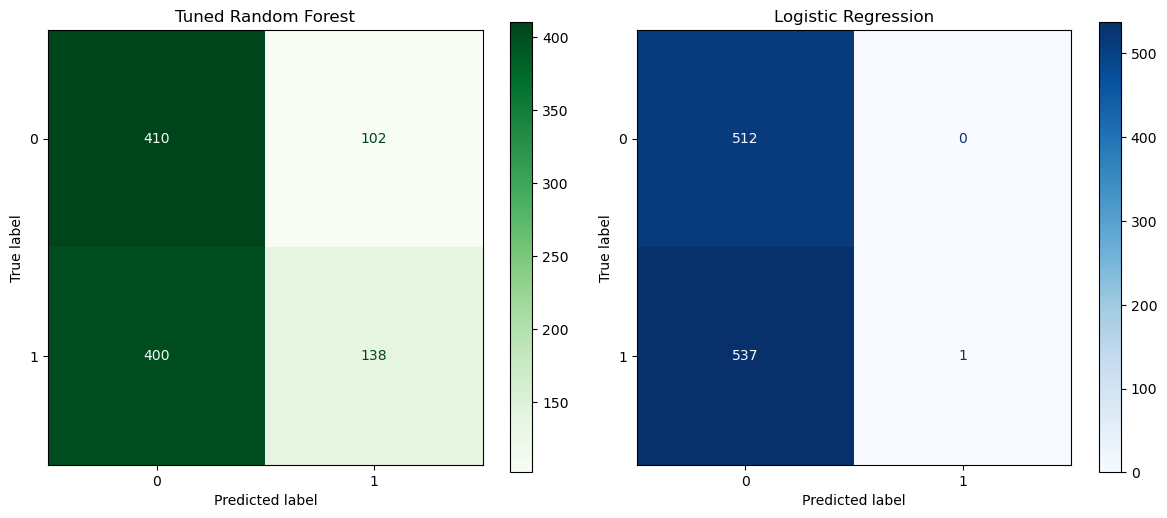

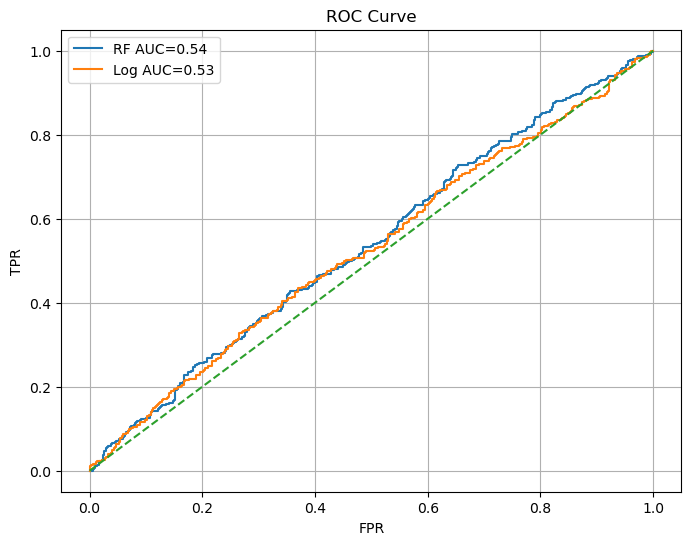

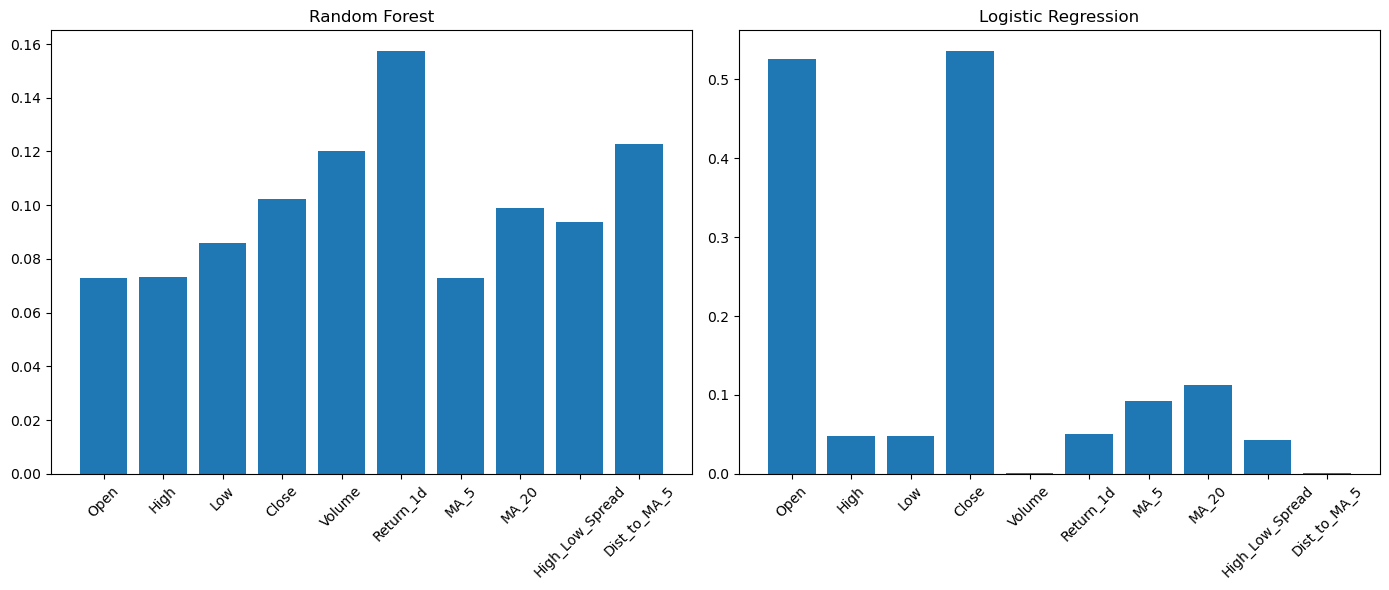


Random Forest Accuracy: 52.19%
Logistic Regression Accuracy: 48.86%

Random Forest Report:
              precision    recall  f1-score   support

           0       0.51      0.80      0.62       512
           1       0.57      0.26      0.35       538

    accuracy                           0.52      1050
   macro avg       0.54      0.53      0.49      1050
weighted avg       0.54      0.52      0.48      1050



In [2]:
# ============================================================
# 1. IMPORTS
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from packaging import version

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    TimeSeriesSplit,
    cross_val_score,
    RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)

# ============================================================
# 2. ENVIRONMENT CHECKS
# ============================================================

MIN_PYTHON = (3, 7)
MIN_SKLEARN = "1.0.1"

if sys.version_info < MIN_PYTHON:
    raise RuntimeError(
        f"Python {MIN_PYTHON[0]}.{MIN_PYTHON[1]}+ required."
    )

if version.parse(sklearn.__version__) < version.parse(MIN_SKLEARN):
    raise RuntimeError(
        f"Scikit-learn {MIN_SKLEARN}+ required."
    )

print("✓ Environment checks passed")

# ============================================================
# 3. LOAD DATA
# ============================================================

DATA_PATH = Path("btcusd_1-min_data_2.csv")


def load_bitcoin_data(path=DATA_PATH):

    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found: {path.resolve()}"
        )

    df = pd.read_csv(path)

    print(f"✓ Bitcoin data loaded ({df.shape[0]:,} rows)")
    return df


bitcoin = load_bitcoin_data()

# ============================================================
# 4. INITIAL DATA PREP
# ============================================================

bitcoin["Datetime"] = pd.to_datetime(
    bitcoin["Timestamp"],
    unit="s"
)

bitcoin = (
    bitcoin
    .set_index("Datetime")
    .drop(columns="Timestamp")
)

# ============================================================
# 5. RESAMPLE TO DAILY DATA
# ============================================================

df_daily = pd.DataFrame({
    "Open": bitcoin["Open"].resample("D").first(),
    "High": bitcoin["High"].resample("D").max(),
    "Low": bitcoin["Low"].resample("D").min(),
    "Close": bitcoin["Close"].resample("D").last(),
    "Volume": bitcoin["Volume"].resample("D").sum(),
})

df_daily.dropna(inplace=True)

print(
    f"✓ Resampled to {df_daily.shape[0]:,} daily observations"
)

# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

df_daily["Next_Close"] = df_daily["Close"].shift(-1)

df_daily["Target"] = (
    df_daily["Next_Close"] > df_daily["Close"]
).astype(int)

df_daily["Return_1d"] = df_daily["Close"].pct_change()

df_daily["MA_5"] = (
    df_daily["Close"]
    .rolling(5)
    .mean()
)

df_daily["MA_20"] = (
    df_daily["Close"]
    .rolling(20)
    .mean()
)

df_daily["High_Low_Spread"] = (
    df_daily["High"] -
    df_daily["Low"]
)

df_daily["Dist_to_MA_5"] = (
    (df_daily["Close"] - df_daily["MA_5"])
    / df_daily["MA_5"]
)

df_daily.dropna(inplace=True)

feature_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return_1d",
    "MA_5",
    "MA_20",
    "High_Low_Spread",
    "Dist_to_MA_5",
]

X = df_daily[feature_cols]
y = df_daily["Target"]

print(f"✓ Training observations: {X.shape[0]}")

print("\nClass distribution:")
print(y.value_counts())

# ============================================================
# 7. CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(
    f"\nTrain: {X_train.shape[0]}"
    f"\nTest : {X_test.shape[0]}"
)

# ============================================================
# 8. MODELS
# ============================================================

log_reg = LogisticRegression(
    max_iter=2000
)

forest_clf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=7,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", log_reg),
])

pipe_forest = Pipeline([
    ("scaler", StandardScaler()),
    ("forest_clf", forest_clf),
])

# ============================================================
# 9. TIME SERIES CROSS-VALIDATION
# ============================================================

tscv = TimeSeriesSplit(n_splits=5)

print("\nRunning CV...")

log_scores = cross_val_score(
    pipe_log,
    X,
    y,
    cv=tscv,
    scoring="accuracy"
)

forest_scores = cross_val_score(
    pipe_forest,
    X,
    y,
    cv=tscv,
    scoring="accuracy"
)

print(
    f"\nLogistic Regression CV:"
    f" {log_scores.mean()*100:.2f}%"
)

print(
    f"Random Forest CV:"
    f" {forest_scores.mean()*100:.2f}%"
)

# ============================================================
# 10. RANDOM FOREST TUNING
# ============================================================

print("\n⏳ Tuning Random Forest...")

param_distributions = {
    "forest_clf__n_estimators": [300, 700, 1200],
    "forest_clf__max_depth": [5, 8, 12, None],
    "forest_clf__min_samples_leaf": [1, 3, 7, 15],
    "forest_clf__min_samples_split": [5, 10, 20, 40],
    "forest_clf__max_features": [
        "sqrt",
        "log2",
        0.4,
        0.6
    ],
    "forest_clf__class_weight": [
        "balanced",
        {0: 1, 1: 1.2},
        {0: 1, 1: 1.5},
        {0: 1, 1: 2.0},
    ],
    "forest_clf__max_samples": [
        0.6,
        0.75,
        1.0
    ],
}

random_search = RandomizedSearchCV(
    estimator=pipe_forest,
    param_distributions=param_distributions,
    n_iter=100,
    cv=tscv,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train, y_train)

pipe_forest = random_search.best_estimator_

print("✓ Tuning complete")
print(random_search.best_params_)

# ============================================================
# 11. TRAIN FINAL MODELS
# ============================================================

pipe_log.fit(X_train, y_train)

y_probs_forest = (
    pipe_forest.predict_proba(X_test)[:, 1]
)

y_probs_log = (
    pipe_log.predict_proba(X_test)[:, 1]
)

# Optimize threshold

train_probs = (
    pipe_forest.predict_proba(X_train)[:, 1]
)

thresholds = np.arange(0.30, 0.65, 0.05)

f1_scores = [
    classification_report(
        y_train,
        (train_probs >= t).astype(int),
        output_dict=True,
        zero_division=0
    )["1"]["f1-score"]
    for t in thresholds
]

custom_threshold = thresholds[
    np.argmax(f1_scores)
]

print(
    f"✓ Optimal threshold:"
    f" {custom_threshold:.2f}"
)

y_pred_forest = (
    y_probs_forest >= custom_threshold
).astype(int)

y_pred_log = (
    y_probs_log >= custom_threshold
).astype(int)

# ============================================================
# 12. CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_forest,
    cmap="Greens",
    ax=axes[0]
)

axes[0].set_title(
    "Tuned Random Forest"
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    cmap="Blues",
    ax=axes[1]
)

axes[1].set_title(
    "Logistic Regression"
)

plt.tight_layout()
plt.show()

# ============================================================
# 13. ROC CURVE
# ============================================================

fpr_forest, tpr_forest, _ = roc_curve(
    y_test,
    y_probs_forest
)

auc_forest = roc_auc_score(
    y_test,
    y_probs_forest
)

fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_probs_log
)

auc_log = roc_auc_score(
    y_test,
    y_probs_log
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_forest,
    tpr_forest,
    label=f"RF AUC={auc_forest:.2f}"
)

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Log AUC={auc_log:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

# ============================================================
# 14. FEATURE IMPORTANCE
# ============================================================

rf_importance = (
    pipe_forest.named_steps["forest_clf"]
    .feature_importances_
)

log_importance = np.abs(
    pipe_log.named_steps["log_reg"]
    .coef_[0]
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

axes[0].bar(
    feature_cols,
    rf_importance
)
axes[0].set_title(
    "Random Forest"
)
axes[0].tick_params(
    axis="x",
    rotation=45
)

axes[1].bar(
    feature_cols,
    log_importance
)
axes[1].set_title(
    "Logistic Regression"
)
axes[1].tick_params(
    axis="x",
    rotation=45
)

plt.tight_layout()
plt.show()

# ============================================================
# 15. FINAL REPORT
# ============================================================

acc_forest = accuracy_score(
    y_test,
    y_pred_forest
)

acc_log = accuracy_score(
    y_test,
    y_pred_log
)

print(
    f"\nRandom Forest Accuracy:"
    f" {acc_forest*100:.2f}%"
)

print(
    f"Logistic Regression Accuracy:"
    f" {acc_log*100:.2f}%"
)

print("\nRandom Forest Report:")
print(
    classification_report(
        y_test,
        y_pred_forest,
        zero_division=0
    )
)